# More Matplotlib

## Problem 1: Line plots
In this problem, we will plot some daily weather data from a NOAA station in Millbrook, NY. A full description of this dataset is available at: https://www.ncdc.noaa.gov/data-access/land-based-station-data
The cell below uses pandas to download the data and populate a bunch of numpy arrays (t_daily_min, t_daily_max, etc.) Run the cell and then use the numpy arrays to try to re-create the plot you see.

In [1]:
import pooch
POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    # Use the figshare DOI
    base_url="doi:10.5281/zenodo.5553029/",
    registry={
        "HEADERS.txt": "md5:2a306ca225fe3ccb72a98953ded2f536",
        "CRND0103-2016-NY_Millbrook_3_W.txt": "md5:eb69811d14d0573ffa69f70dd9c768d9",
        "CRND0103-2017-NY_Millbrook_3_W.txt": "md5:b911da727ba1bdf26a34a775f25d1088",
        "CRND0103-2018-NY_Millbrook_3_W.txt": "md5:5b61bc687261596eba83801d7080dc56",
        "CRND0103-2019-NY_Millbrook_3_W.txt": "md5:9b814430612cd8a770b72020ca4f2b7d",
        "CRND0103-2020-NY_Millbrook_3_W.txt": "md5:cd8de6d5445024ce35fcaafa9b0e7b64"
    },
)


import pandas as pd

with open(POOCH.fetch("HEADERS.txt")) as fp:
    data = fp.read()
lines = data.split('\n')
headers = lines[1].split(' ')

dframes = []
for year in range(2016, 2019):
    fname = f'CRND0103-{year}-NY_Millbrook_3_W.txt'               
    df = pd.read_csv(POOCH.fetch(fname), parse_dates=[1],
                     names=headers, header=None, sep='\s+',
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index('LST_DATE')
df

,WBANNO,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,SOLARAD_DAILY,...,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY,
LST_DATE,,,,,,,,,,,,,,,,,,,,,
2016-01-01,64756,2.422,-73.74,41.79,3.4,-0.5,1.5,1.3,0.0,1.69,...,0.233,0.204,0.155,0.147,4.2,4.4,5.1,6.0,7.6,NaN
2016-01-02,64756,2.422,-73.74,41.79,2.9,-3.6,-0.4,-0.3,0.0,6.25,...,0.227,0.199,0.152,0.144,2.8,3.1,4.2,5.7,7.4,NaN
2016-01-03,64756,2.422,-73.74,41.79,5.1,-1.8,1.6,1.1,0.0,5.69,...,0.223,0.196,0.151,0.141,2.6,2.8,3.8,5.2,7.2,NaN
2016-01-04,64756,2.422,-73.74,41.79,0.5,-14.4,-6.9,-7.5,0.0,9.17,...,0.220,0.194,0.148,0.139,1.7,2.1,3.4,4.9,6.9,NaN
2016-01-05,64756,2.422,-73.74,41.79,-5.2,-15.5,-10.3,-11.7,0.0,9.34,...,0.213,0.191,0.148,0.138,0.4,0.9,2.4,4.3,6.6,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-27,64756,2.622,-73.74,41.79,2.5,-2.1,0.2,0.3,0.0,7.50,...,0.275,0.248,0.191,0.192,1.3,1.4,1.9,3.2,4.7,NaN
2018-12-28,64756,2.622,-73.74,41.79,11.6,1.9,6.8,7.6,11.5,0.45,...,0.295,0.261,0.193,0.191,2.9,2.7,2.5,3.1,4.5,NaN
2018-12-29,64756,2.622,-73.74,41.79,11.3,-2.1,4.6,6.3,0.0,4.89,...,0.295,0.270,0.208,0.191,4.5,4.4,4.0,3.8,4.5,NaN


In [2]:
t_daily_min = df.T_DAILY_MIN.values
t_daily_max = df.T_DAILY_MAX.values
t_daily_mean = df.T_DAILY_MEAN.values
p_daily_calc = df.P_DAILY_CALC.values
soil_moisture_5 = df.SOIL_MOISTURE_5_DAILY.values
soil_moisture_10 = df.SOIL_MOISTURE_10_DAILY.values
soil_moisture_20 = df.SOIL_MOISTURE_20_DAILY.values
soil_moisture_50 = df.SOIL_MOISTURE_50_DAILY.values
soil_moisture_100 = df.SOIL_MOISTURE_100_DAILY.values
date = df.index.values

In [3]:
units = lines[2].split(' ')
for name, unit in zip(headers, units):
    print(f'{name}: {unit}')

WBANNO: XXXXX
LST_DATE: YYYYMMDD
CRX_VN: XXXXXX
LONGITUDE: Decimal_degrees
LATITUDE: Decimal_degrees
T_DAILY_MAX: Celsius
T_DAILY_MIN: Celsius
T_DAILY_MEAN: Celsius
T_DAILY_AVG: Celsius
P_DAILY_CALC: mm
SOLARAD_DAILY: MJ/m^2
SUR_TEMP_DAILY_TYPE: X
SUR_TEMP_DAILY_MAX: Celsius
SUR_TEMP_DAILY_MIN: Celsius
SUR_TEMP_DAILY_AVG: Celsius
RH_DAILY_MAX: %
RH_DAILY_MIN: %
RH_DAILY_AVG: %
SOIL_MOISTURE_5_DAILY: m^3/m^3
SOIL_MOISTURE_10_DAILY: m^3/m^3
SOIL_MOISTURE_20_DAILY: m^3/m^3
SOIL_MOISTURE_50_DAILY: m^3/m^3
SOIL_MOISTURE_100_DAILY: m^3/m^3
SOIL_TEMP_5_DAILY: Celsius
SOIL_TEMP_10_DAILY: Celsius
SOIL_TEMP_20_DAILY: Celsius
SOIL_TEMP_50_DAILY: Celsius
SOIL_TEMP_100_DAILY: Celsius
: 


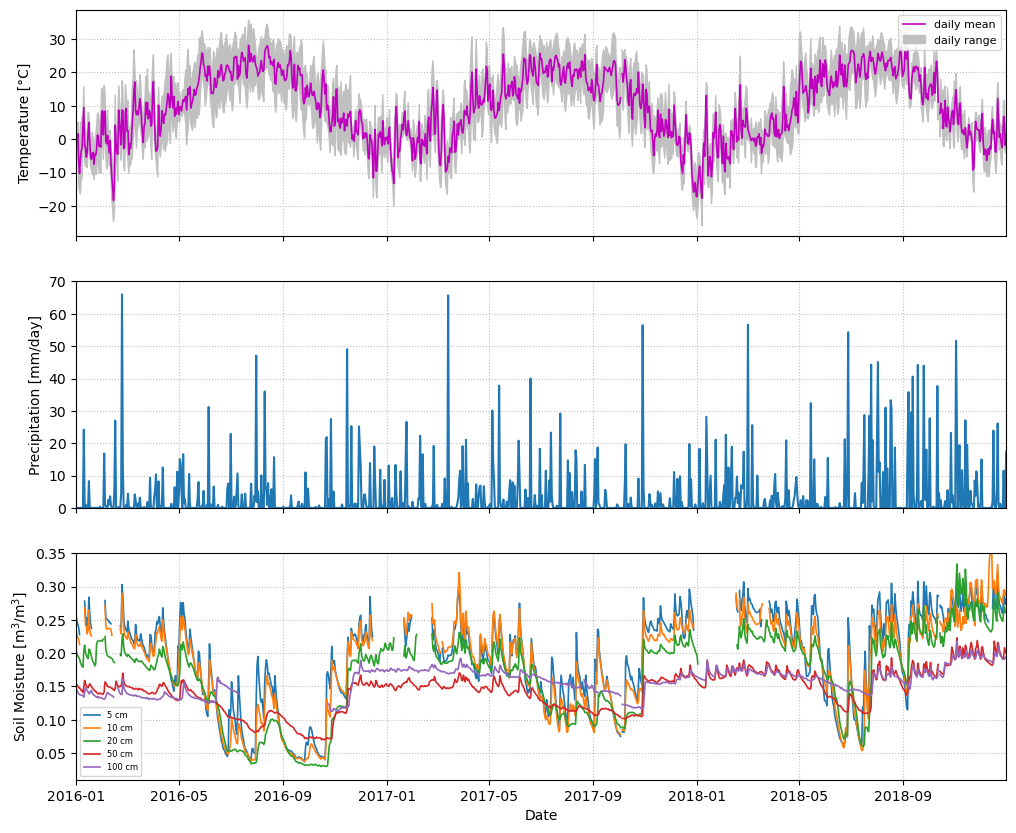

In [70]:
import numpy as np
from matplotlib import pyplot as plt

dates = date.astype('datetime64[ms]').astype('O')

Fig,axes = plt.subplots(nrows=3, figsize=(12,10))

# Plot 1: Temperature
axes[0].grid(linestyle=':', color='silver')
axes[0].set_xlim(dates[0], dates[-1])

axes[0].plot(dates, t_daily_mean, label='daily mean', color='m', linewidth=1.2)
axes[0].fill_between(dates, t_daily_min, t_daily_max, label='daily range', color='silver')

axes[0].set_ylabel('Temperature [°C]')
axes[0].tick_params(labelbottom=False)
axes[0].legend(loc='upper right', fontsize=8)

#Plot 2: Precipitation
axes[1].grid(linestyle=':', color='silver')
axes[1].set_xlim(dates[0], dates[-1])
axes[1].set_ylim(p_daily_calc[0], 70)

axes[1].plot(dates, p_daily_calc, color='tab:blue')

axes[1].set_ylabel('Precipitation [mm/day]')
axes[1].tick_params(labelbottom=False)

#Plot 3: Soil Moisture
axes[2].grid(linestyle=':', color='silver')
axes[2].set_xlim(dates[0], dates[-1])
axes[2].set_ylim(0.01, 0.35)

axes[2].plot(dates, soil_moisture_5, label='5 cm', color='tab:blue', linewidth=1.2)
axes[2].plot(dates, soil_moisture_10, label='10 cm', color='tab:orange', linewidth=1.2)
axes[2].plot(dates, soil_moisture_20, label='20 cm', color='tab:green', linewidth=1.2)
axes[2].plot(dates, soil_moisture_50, label='50 cm', color='tab:red', linewidth=1.2)
axes[2].plot(dates, soil_moisture_100, label='100 cm', color='tab:purple', linewidth=1.2)

axes[2].set_ylabel('Soil Moisture [m$^3$/m$^3$]')
axes[2].set_xlabel('Date')
axes[2].legend(loc='lower left', fontsize=6)

## Problem 2: Contour Plots
Now we will visualize some global temperature data from the NCEP-NCAR atmospheric reanalysis.

In [6]:
import xarray as xr
ds_url = 'http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods'
ds = xr.open_dataset(ds_url, decode_times=False)

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays) 
#### NO XARRAY ALLOWED!
#########################################################

In [7]:
temp = ds.temp[-1].values - 273.15
lon = ds.X.values
lat = ds.Y.values

In [8]:
print(temp.shape, lat.shape, lon.shape)

(94, 192) (94,) (192,)


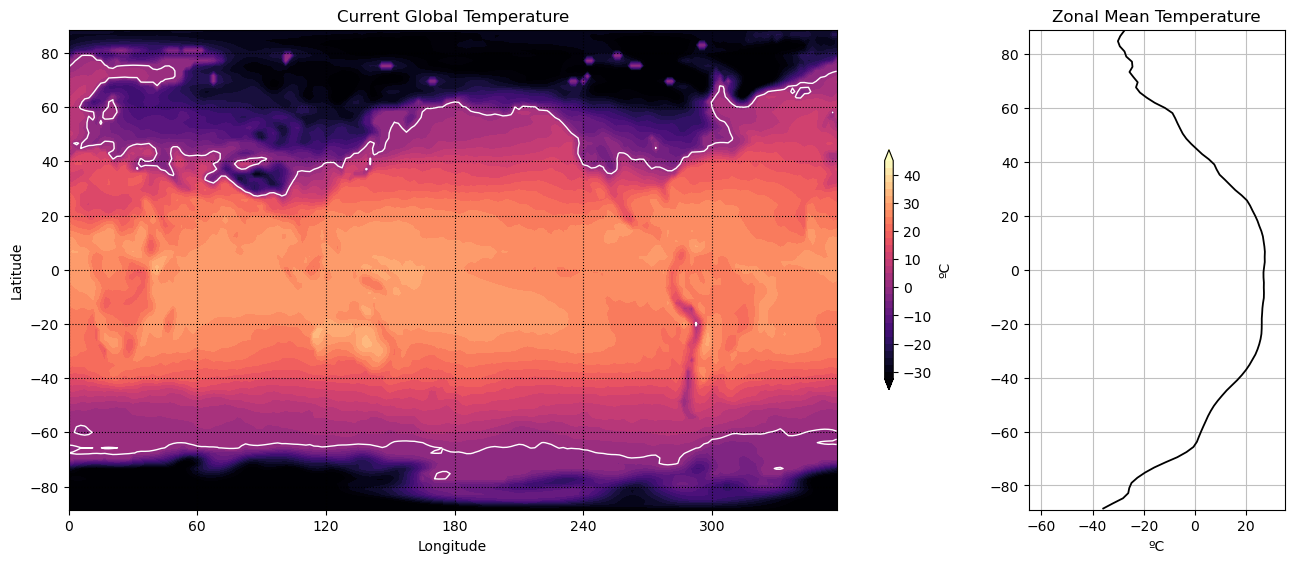

In [71]:
fig = plt.figure()
ax1 = fig.add_axes([0,0,1.5,1])
ax2 = fig.add_axes([1.5,0,0.4,1])

# Plot 1: Current Global Temperature
levels=np.arange(-32.5, 47.5, 2.5)
plot1 = ax1.contourf(lon, lat, temp, levels=levels, cmap='magma', extend='both')
ax1.grid(linestyle='dotted', color='black')
ax1.contour(lon, lat, temp, levels=[0], colors='white', linewidths=1)

ax1.set_ylabel('Latitude')
ax1.set_xlabel('Longitude')
ax1.set_xticks(range(0, 360, 60))
ax1.set_title('Current Global Temperature')
fig.colorbar(plot1, label='ºC', aspect = 28, shrink=0.5)

# Plot 2: Zonal Mean Temperature
meantemp = np.nanmean(temp, axis=1)
plot2 = ax2.plot(meantemp, lat, color='black', linewidth = 1.3)

ax2.set_xlabel('ºC')
ax2.set_xlim(-65, 35)
ax2.set_ylim(-89,89)
ax2.set_title('Zonal Mean Temperature')
ax2.grid(color='silver')

## Problem 3: Scatter plots
Here we will make a map plot of earthquakes from a USGS catalog of historic large earthquakes. Color the earthquakes by log10(depth) and adjust the marker size to be magntiude$^4$/100

In [42]:
fname = pooch.retrieve(
    "https://rabernat.github.io/research_computing/signif.txt.tsv.zip",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes = np.genfromtxt(fname, delimiter='\t')
depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

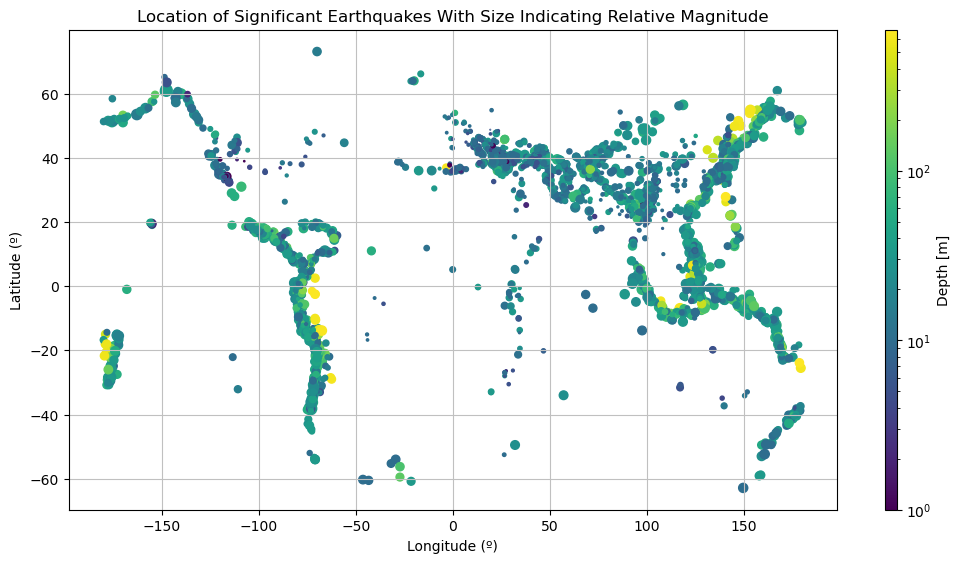

In [67]:
from matplotlib.colors import LogNorm

valid = depth > 0
depth_valid = depth[valid]

norm = LogNorm(vmin=np.nanmin(depth_valid), vmax=np.nanmax(depth_valid))
s = magnitude**4/100

fig = plt.figure()
ax1 = fig.add_axes([0,0,1.5,1])
ax1.grid(color='silver')
plot = plt.scatter(longitude, latitude, c=depth, norm=norm, cmap='viridis', s=s)
cbar = fig.colorbar(plot, ax=ax1, label='Depth [m]', aspect = 40)
ax1.set_title('Location of Significant Earthquakes With Size Indicating Relative Magnitude')
ax1.set_ylabel('Latitude (º)')
ax1.set_xlabel('Longitude (º)')

plt.show()